# Word Embeddings via Matrix Factorization

This notebook builds word vector representations **from scratch** using truncated SVD applied to a PPMI-weighted co-occurrence matrix, following the Eckart–Young theorem for optimal low-rank approximation.

**Pipeline:**
1. Load & preprocess the Text8 corpus
2. Build a sparse co-occurrence matrix (V=10,000, window=5)
3. Apply PPMI weighting
4. Compute truncated SVD → word vectors
5. Evaluate: nearest neighbours + Google Analogy Benchmark
6. Compare: k values, embedding variants, baselines (GloVe, Word2Vec)

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd

## 1. Data Loading & Vocabulary

The **Text8** dataset contains ~17 million tokens of cleaned Wikipedia text (lowercase, no punctuation). We build a vocabulary of the top 10,000 most frequent words.

In [2]:
from src.preprocessing import load_corpus, build_vocab, build_cooccurrence

tokens = load_corpus("../data/text8_100mb")
print(f"Corpus size: {len(tokens):,} tokens")
print(f"First 20 tokens: {tokens[:20]}")

Corpus size: 17,005,207 tokens
First 20 tokens: ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working', 'class', 'radicals', 'including', 'the', 'diggers', 'of', 'the', 'english']


In [3]:
V = 10_000
word2idx, idx2word = build_vocab(tokens, max_vocab=V)
print(f"Vocabulary size: {len(word2idx):,}")
print(f"\nTop 20 words:")
from collections import Counter
counts = Counter(tokens)
for i, word in enumerate(idx2word[:20]):
    print(f"  {i+1:3d}. {word:15s} {counts[word]:>8,}")

Vocabulary size: 10,000

Top 20 words:
    1. the             1,061,396
    2. of               593,677
    3. and              416,629
    4. one              411,764
    5. in               372,201
    6. a                325,873
    7. to               316,376
    8. zero             264,975
    9. nine             250,430
   10. two              192,644
   11. is               183,153
   12. as               131,815
   13. eight            125,285
   14. for              118,445
   15. s                116,710
   16. five             115,789
   17. three            114,775
   18. was              112,807
   19. by               111,831
   20. that             109,510


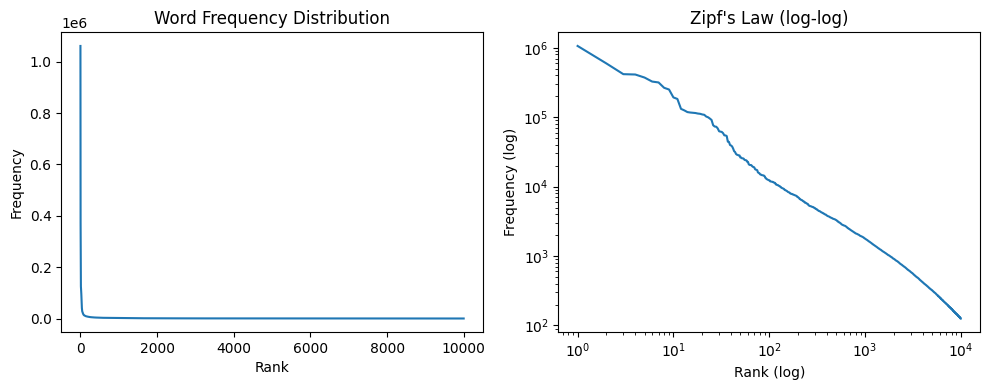

In [4]:
# Word frequency distribution (Zipf's law)
freqs = [counts[w] for w in idx2word]
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(freqs)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Word Frequency Distribution")

plt.subplot(1, 2, 2)
plt.loglog(range(1, len(freqs) + 1), freqs)
plt.xlabel("Rank (log)")
plt.ylabel("Frequency (log)")
plt.title("Zipf's Law (log-log)")
plt.tight_layout()
plt.show()

## 2. Co-occurrence Matrix

We build a sparse symmetric co-occurrence matrix $M \in \mathbb{R}^{V \times V}$ where $M_{ij}$ counts how often words $i$ and $j$ appear within a window of 5 tokens of each other.

> **Note:** This step takes a few minutes on 17M tokens.

In [5]:
cooc = build_cooccurrence(tokens, word2idx, window=5)

print(f"Shape: {cooc.shape}")
print(f"Non-zero entries: {cooc.nnz:,}")
print(f"Density: {cooc.nnz / (V * V) * 100:.2f}%")
print(f"Is symmetric: {(cooc - cooc.T).nnz == 0}")

Building co-occurrence matrix: 100%|██████████| 17005207/17005207 [05:39<00:00, 50126.30it/s]


Shape: (10000, 10000)
Non-zero entries: 13,774,189
Density: 13.77%
Is symmetric: True


In [6]:
# Sanity check: co-occurrence counts for some word pairs
check_pairs = [("king", "queen"), ("the", "of"), ("dog", "cat"), ("man", "woman")]
print("Co-occurrence counts:")
for w1, w2 in check_pairs:
    if w1 in word2idx and w2 in word2idx:
        count = cooc[word2idx[w1], word2idx[w2]]
        print(f"  ({w1}, {w2}): {count:.0f}")

Co-occurrence counts:
  (king, queen): 108
  (the, of): 600704
  (dog, cat): 15
  (man, woman): 167


## 3. PPMI Weighting

Raw co-occurrence counts are dominated by frequent words ("the", "of", etc.). **PPMI** (Positive Pointwise Mutual Information) corrects for this:

$$\text{PPMI}(i,j) = \max\left(\log_2 \frac{P(i,j)}{P(i)\,P(j)},\ 0\right)$$

This highlights genuinely associated word pairs while suppressing spurious high-frequency co-occurrences.

In [7]:
from src.ppmi import compute_ppmi

ppmi_matrix = compute_ppmi(cooc)

print(f"PPMI non-zero entries: {ppmi_matrix.nnz:,}")
print(f"Min value: {ppmi_matrix.data.min():.4f} (should be > 0)")
print(f"Max value: {ppmi_matrix.data.max():.4f}")
print(f"Mean (non-zero): {ppmi_matrix.data.mean():.4f}")

PPMI non-zero entries: 10,582,334
Min value: 0.0000 (should be > 0)
Max value: 15.4516
Mean (non-zero): 2.1923


In [8]:
# Before/after PPMI comparison
print("Raw count vs PPMI for selected word pairs:")
print(f"{'Pair':<25s} {'Raw Count':>10s} {'PPMI':>10s}")
print("-" * 47)
for w1, w2 in check_pairs:
    if w1 in word2idx and w2 in word2idx:
        i, j = word2idx[w1], word2idx[w2]
        raw = cooc[i, j]
        ppmi_val = ppmi_matrix[i, j]
        print(f"({w1}, {w2}){'':<{20-len(w1)-len(w2)}} {raw:>10.0f} {ppmi_val:>10.4f}")

Raw count vs PPMI for selected word pairs:
Pair                       Raw Count       PPMI
-----------------------------------------------
(king, queen)                   108     3.6736
(the, of)                    600704     0.6954
(dog, cat)                       15     5.5177
(man, woman)                    167     4.8236


## 4. Truncated SVD & Word Vectors

We decompose the PPMI matrix using truncated SVD:

$$M_{\text{PPMI}} \approx U_k \Sigma_k V_k^T$$

The word vectors are computed as $E = U_k \sqrt{\Sigma_k}$ (symmetric weighting), which balances the contribution of singular values between left and right singular vectors.

In [9]:
from src.svd import compute_embeddings, get_word_vectors

k = 300
svd_result = compute_embeddings(ppmi_matrix, k=k)
U, S, Vt = svd_result["U"], svd_result["S"], svd_result["Vt"]

print(f"U shape: {U.shape}")
print(f"Singular values (top 10): {S[:10].round(2)}")
print(f"Singular values (bottom 5): {S[-5:].round(2)}")

U shape: (10000, 300)
Singular values (top 10): [2540.62 1028.47  837.01  789.96  684.71  658.17  596.04  579.43  577.21
  510.69]
Singular values (bottom 5): [156.15 156.06 155.95 155.85 155.79]


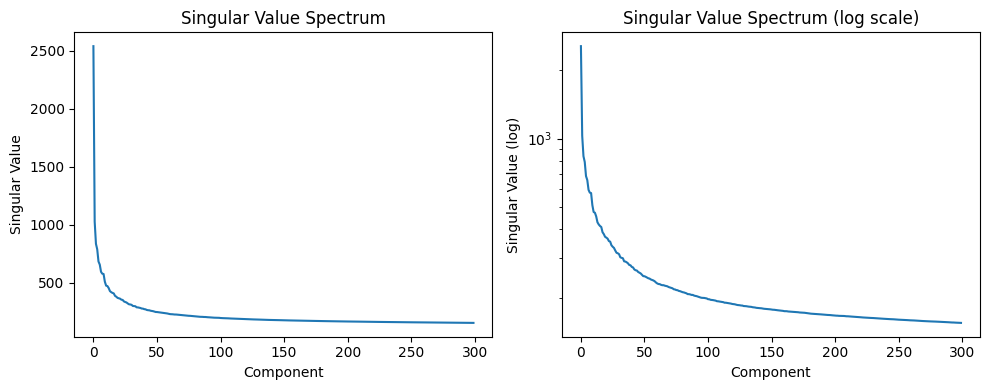

In [10]:
# Singular value spectrum
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(S)
plt.xlabel("Component")
plt.ylabel("Singular Value")
plt.title("Singular Value Spectrum")

plt.subplot(1, 2, 2)
plt.semilogy(S)
plt.xlabel("Component")
plt.ylabel("Singular Value (log)")
plt.title("Singular Value Spectrum (log scale)")
plt.tight_layout()
plt.show()

In [11]:
from src.evaluation import normalize, nearest_neighbours, analogy

E = get_word_vectors(U, S, variant="sqrt")
E_norm = normalize(E)

print("Quick sanity check — nearest neighbours for 'king':")
for word, score in nearest_neighbours("king", E_norm, idx2word, word2idx, n=10):
    print(f"  {word:15s} {score:.4f}")

Quick sanity check — nearest neighbours for 'king':
  iii             0.6688
  ii              0.6561
  crowned         0.6460
  kings           0.6452
  son             0.6366
  throne          0.6364
  iv              0.6289
  vii             0.6224
  prince          0.6117
  queen           0.6072


## 5. Evaluation — Nearest Neighbours

Testing whether the learned vectors capture semantic similarity.

In [12]:
query_words = ["king", "dog", "computer", "france", "good"]

for qword in query_words:
    neighbours = nearest_neighbours(qword, E_norm, idx2word, word2idx, n=5)
    neighbour_str = ", ".join(f"{w} ({s:.3f})" for w, s in neighbours)
    print(f"{qword:12s} → {neighbour_str}")


king         → iii (0.669), ii (0.656), crowned (0.646), kings (0.645), son (0.637)
dog          → breed (0.565), dogs (0.547), cat (0.530), breeds (0.528), goat (0.465)
computer     → computers (0.750), computing (0.676), hardware (0.637), machines (0.610), systems (0.563)
france       → spain (0.656), italy (0.606), netherlands (0.592), germany (0.573), belgium (0.552)
good         → you (0.497), bad (0.491), your (0.460), things (0.433), what (0.432)


## 6. Evaluation — Word Analogies

Testing the classic analogy task: **a is to b as c is to ?**

The answer is computed as $\vec{b} - \vec{a} + \vec{c}$, then finding the nearest neighbour.

In [13]:
# Demo analogies
analogy_tests = [
    ("man", "king", "woman"),       # gender: king - man + woman ≈ queen
    ("france", "paris", "germany"), # capital: paris - france + germany ≈ berlin
    ("good", "better", "bad"),      # comparative: better - good + bad ≈ worse
    ("man", "men", "woman"),        # plural: men - man + woman ≈ women
]

print(f"{'a':>10s}  {'b':>10s}  {'c':>10s}  →  top predictions")
print("-" * 65)
for a, b, c in analogy_tests:
    results = analogy(a, b, c, E_norm, idx2word, word2idx, n=3)
    preds = ", ".join(f"{w} ({s:.3f})" for w, s in results)
    print(f"{a:>10s}  {b:>10s}  {c:>10s}  →  {preds}")

         a           b           c  →  top predictions
-----------------------------------------------------------------
       man        king       woman  →  queen (0.577), throne (0.558), crowned (0.514)
    france       paris     germany  →  munich (0.676), berlin (0.673), vienna (0.570)
      good      better         bad  →  worse (0.415), faster (0.300), improved (0.297)
       man         men       woman  →  women (0.727), male (0.534), female (0.486)


### Google Analogy Benchmark

The standard benchmark with 19,544 analogy questions across 14 categories (semantic + syntactic).

In [14]:
import os
import urllib.request

# Download Google Analogy Benchmark if not present
benchmark_path = "../data/questions-words.txt"
if not os.path.exists(benchmark_path):
    url = "https://raw.githubusercontent.com/nicholas-leonard/word2vec/master/questions-words.txt"
    print("Downloading Google Analogy Benchmark...")
    urllib.request.urlretrieve(url, benchmark_path)
    print("Done.")
else:
    print(f"Benchmark already exists at {benchmark_path}")

Done.


In [15]:
from src.evaluation import load_google_analogy, evaluate_analogy_benchmark

categories = load_google_analogy(benchmark_path)
print(f"Loaded {sum(len(v) for v in categories.values()):,} questions in {len(categories)} categories")
for cat, qs in categories.items():
    print(f"  {cat}: {len(qs)} questions")

Loaded 19,544 questions in 14 categories
  capital-common-countries: 506 questions
  capital-world: 4524 questions
  currency: 866 questions
  city-in-state: 2467 questions
  family: 506 questions
  gram1-adjective-to-adverb: 992 questions
  gram2-opposite: 812 questions
  gram3-comparative: 1332 questions
  gram4-superlative: 1122 questions
  gram5-present-participle: 1056 questions
  gram6-nationality-adjective: 1599 questions
  gram7-past-tense: 1560 questions
  gram8-plural: 1332 questions
  gram9-plural-verbs: 870 questions


In [16]:
results = evaluate_analogy_benchmark(E_norm, idx2word, word2idx, categories)

# Display per-category results
rows = []
for cat, r in results["per_category"].items():
    rows.append({
        "Category": cat,
        "Correct": r["correct"],
        "Evaluated": r["total"],
        "OOV Skipped": r["oov_skipped"],
        "Accuracy": f"{r['accuracy']:.1%}",
    })

df = pd.DataFrame(rows)
display(df)

print(f"\nOverall accuracy: {results['overall_accuracy']:.1%}")
print(f"Total: {results['total_correct']}/{results['total_evaluated']} correct, {results['total_oov_skipped']} OOV skipped")

,Category,Correct,Evaluated,OOV Skipped,Accuracy
0,capital-common-countries,148,210,296,70.5%
1,capital-world,136,200,4324,68.0%
2,currency,1,28,838,3.6%
3,city-in-state,171,420,2047,40.7%
4,family,112,156,350,71.8%
5,gram1-adjective-to-adverb,23,342,650,6.7%
6,gram2-opposite,8,42,770,19.0%
7,gram3-comparative,278,552,780,50.4%
8,gram4-superlative,63,240,882,26.2%
9,gram5-present-participle,163,552,504,29.5%



Overall accuracy: 47.9%
Total: 2610/5451 correct, 14093 OOV skipped


## 7. Comparison — Effect of k

We run the full benchmark for $k \in \{50, 100, 200, 300, 500\}$ to find the optimal dimensionality.

In [17]:
# TODO: Comparison of different k values
# ========================================
# This section runs SVD for multiple k values and benchmarks each.
# It reuses the same ppmi_matrix (already computed above).
# Each SVD call takes ~30-60s so the full sweep may take a few minutes.
#
# Steps:
# 1. For each k in [50, 100, 200, 300, 500]:
#    - compute_embeddings(ppmi_matrix, k=k)
#    - get_word_vectors(U, S, variant="sqrt")
#    - normalize, then evaluate_analogy_benchmark
#    - store overall_accuracy
# 2. Plot accuracy vs k
# 3. Show results table
#
# Expected output: accuracy should generally increase with k, possibly
# plateauing or slightly dropping at k=500 due to noise in tail singular values.

k_values = [50, 100, 200, 300, 500]
k_results = {}

for k_val in k_values:
    print(f"Running SVD with k={k_val}...")
    svd_k = compute_embeddings(ppmi_matrix, k=k_val)
    E_k = get_word_vectors(svd_k["U"], svd_k["S"], variant="sqrt")
    E_k_norm = normalize(E_k)
    res = evaluate_analogy_benchmark(E_k_norm, idx2word, word2idx, categories)
    k_results[k_val] = res["overall_accuracy"]
    print(f"  k={k_val}: accuracy = {res['overall_accuracy']:.1%}")

print("\nDone.")

Running SVD with k=50...
  k=50: accuracy = 33.2%
Running SVD with k=100...
  k=100: accuracy = 42.4%
Running SVD with k=200...
  k=200: accuracy = 47.6%
Running SVD with k=300...
  k=300: accuracy = 47.9%
Running SVD with k=500...
  k=500: accuracy = 46.7%

Done.


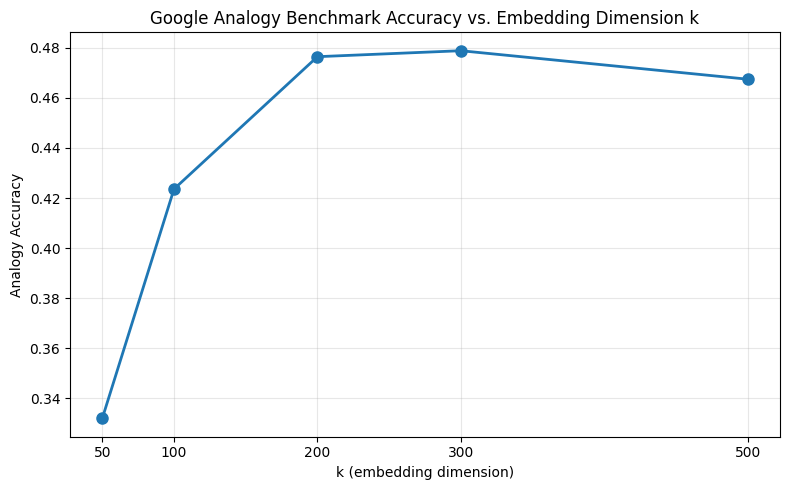

,k,Accuracy
0,50,33.2%
1,100,42.4%
2,200,47.6%
3,300,47.9%
4,500,46.7%


In [18]:
# TODO: Plot accuracy vs k
# ========================================
# Create a line plot showing how analogy accuracy changes with k.
# Consider adding a horizontal dashed line for the best-performing k.

plt.figure(figsize=(8, 5))
plt.plot(list(k_results.keys()), list(k_results.values()), "o-", linewidth=2, markersize=8)
plt.xlabel("k (embedding dimension)")
plt.ylabel("Analogy Accuracy")
plt.title("Google Analogy Benchmark Accuracy vs. Embedding Dimension k")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Results table
df_k = pd.DataFrame([
    {"k": k, "Accuracy": f"{acc:.1%}"}
    for k, acc in k_results.items()
])
display(df_k)

## 8. Comparison — Embedding Variants

The report specifies three embedding variants derived from the SVD decomposition:
- **Plain:** $U_k$ — raw left singular vectors
- **Weighted:** $U_k \Sigma_k$ — fully weighted by singular values
- **Sqrt:** $U_k \sqrt{\Sigma_k}$ — symmetric weighting (our default)

In [19]:
# TODO: Compare embedding variants on the analogy benchmark
# ========================================
# Uses the k=300 SVD result already computed (U, S from Section 4).
# For each variant, compute word vectors, normalize, and run benchmark.
#
# If results for k=300 are already in k_results from Section 7,
# the "sqrt" result here should match. This serves as a consistency check.

variants = ["plain", "weighted", "sqrt"]
variant_results = {}

for var in variants:
    E_var = get_word_vectors(U, S, variant=var)
    E_var_norm = normalize(E_var)
    res = evaluate_analogy_benchmark(E_var_norm, idx2word, word2idx, categories)
    variant_results[var] = res["overall_accuracy"]
    print(f"Variant '{var}': accuracy = {res['overall_accuracy']:.1%}")

df_var = pd.DataFrame([
    {"Variant": v, "Formula": f, "Accuracy": f"{variant_results[v]:.1%}"}
    for v, f in zip(variants, ["U_k", "U_k · Σ_k", "U_k · √Σ_k"])
])
display(df_var)

Variant 'plain': accuracy = 44.7%
Variant 'weighted': accuracy = 48.4%
Variant 'sqrt': accuracy = 47.9%


,Variant,Formula,Accuracy
0,plain,U_k,44.7%
1,weighted,U_k · Σ_k,48.4%
2,sqrt,U_k · √Σ_k,47.9%


## 9. Comparison — Baselines

We compare our PPMI+SVD embeddings against:
1. **Raw co-occurrence cosine similarity** — no dimensionality reduction (naive baseline)
2. **GloVe** (300d, pre-trained on Wikipedia) — count-based neural alternative
3. **Word2Vec Skip-Gram** (300d, pre-trained on Google News) — neural SoTA reference

In [20]:
# TODO: Baseline comparisons
# ========================================
# This section requires downloading pretrained embeddings.
# The code is ready but you need to provide the file paths.
#
# --- BASELINE 1: Raw co-occurrence cosine (no download needed) ---
# from src.baselines import cosine_baseline_vectors
# E_raw = cosine_baseline_vectors(cooc)  # already normalized
# res_raw = evaluate_analogy_benchmark(E_raw, idx2word, word2idx, categories)
# print(f"Raw co-occurrence cosine: {res_raw['overall_accuracy']:.1%}")
#
# --- BASELINE 2: GloVe ---
# Download: https://nlp.stanford.edu/data/glove.6B.zip
# Extract glove.6B.300d.txt and place in data/
#
# from src.baselines import load_glove
# E_glove = load_glove("../data/glove.6B.300d.txt", word2idx, dim=300)
# E_glove_norm = normalize(E_glove)
# res_glove = evaluate_analogy_benchmark(E_glove_norm, idx2word, word2idx, categories)
# print(f"GloVe 300d: {res_glove['overall_accuracy']:.1%}")
#
# --- BASELINE 3: Word2Vec ---
# Download: https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM
# (GoogleNews-vectors-negative300.bin.gz — 1.5GB compressed)
#
# from src.baselines import load_word2vec
# E_w2v = load_word2vec("../data/GoogleNews-vectors-negative300.bin", word2idx)
# E_w2v_norm = normalize(E_w2v)
# res_w2v = evaluate_analogy_benchmark(E_w2v_norm, idx2word, word2idx, categories)
# print(f"Word2Vec 300d: {res_w2v['overall_accuracy']:.1%}")
#
# --- FINAL COMPARISON TABLE ---
# comparison = {
#     "Raw Co-occurrence": res_raw["overall_accuracy"],
#     "PPMI + SVD (ours, k=300)": results["overall_accuracy"],
#     "GloVe 300d": res_glove["overall_accuracy"],
#     "Word2Vec 300d": res_w2v["overall_accuracy"],
# }
# df_compare = pd.DataFrame([
#     {"Method": m, "Accuracy": f"{a:.1%}"} for m, a in comparison.items()
# ])
# display(df_compare)
#
# --- BAR CHART ---
# plt.figure(figsize=(8, 5))
# plt.bar(comparison.keys(), comparison.values())
# plt.ylabel("Analogy Accuracy")
# plt.title("Method Comparison on Google Analogy Benchmark")
# plt.xticks(rotation=15)
# plt.tight_layout()
# plt.show()

print("⚠️  Baseline comparisons are commented out — uncomment after downloading pretrained vectors.")
print("    See comments above for download links.")

⚠️  Baseline comparisons are commented out — uncomment after downloading pretrained vectors.
    See comments above for download links.


## 10. t-SNE Visualization

> **TODO:** Project 500 selected words to 2D using t-SNE to verify semantic cluster formation.

```python
# TODO: t-SNE visualization
# ========================================
# Steps:
# 1. Pick ~500 words (e.g. top 500 by frequency, or curated semantic groups)
# 2. from sklearn.manifold import TSNE
# 3. tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# 4. E_2d = tsne.fit_transform(E_norm[:500])
# 5. Scatter plot with word labels for interesting clusters
# 6. Consider coloring by category (countries, animals, etc.) for clarity
#
# Tips:
# - Use a curated word list for cleaner visualization
# - Annotate only a subset of points to avoid clutter
# - Try different perplexity values (5, 30, 50) to see effect
```